<a href="https://colab.research.google.com/github/Simaycims/-datasciencecoursera/blob/master/Eve_Cosmetics_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can install Python libraries using `pip install` followed by the library name. For example, to install the `pandas` library, you would run the following command in a code cell:

In [4]:
!pip install pandas

After installation, you can import and use the library in your code:

In [5]:
import pandas as pd
print(pd.__version__)

2.2.2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
'/content/drive/MyDrive/EVE/combined_sales_2022-2025.csv'

'/content/drive/MyDrive/EVE/combined_sales_2022-2025.csv'

In [8]:
import pandas as pd

dosya_yolu = '/content/drive/MyDrive/EVE/combined_sales_2022-2025.csv'

# Dosyayı tek seferde yüklemiyoruz, sadece ilk 100.000 satırı okuyup test ediyoruz
df_test = pd.read_csv(dosya_yolu, nrows=100000)

# Veri geldi mi diye kontrol et
print(df_test.head())
print("Test başarılı, ilk 100 bin satır okundu!")

         trans_id               trans_date  store_code  cust_id  product_code  \
0  40020000120599  2022-01-01 12:42:47.000        1002  3180353       1024429   
1  40020000120600  2022-01-01 12:49:44.000        1002  3826520       1019353   
2  40020000120603  2022-01-01 13:37:29.000        1002        0       1010998   
3  40020000120607  2022-01-01 13:56:20.000        1002        0       1001643   
4  40020000120614  2022-01-01 14:50:59.000        1002        0       1001938   

         barcode  amount unit_price no_discount discounted_unit_price  \
0  8683280800762       1       8,99        8,99                  6,99   
1  8690530001350       1       2,25        2,25                  2,25   
2  3574661610337       1      20,95       29,95                 20,95   
3  8717163736944       1      21,95       39,25                 21,95   
4  8691900172724       1      17,97       29,95                 17,97   

  discounted_total_price total_discount_amount unit_campaign_discount  
0 

In [10]:
import polars as pl

# Veriyi tara ama henüz RAM'e yükleme (Lazy)
# decimal_comma=True sayesinde 8,99 sayıya dönüşür
df = pl.scan_csv('/content/drive/MyDrive/EVE/combined_sales_2022-2025.csv',
                 separator=',',
                 decimal_comma=True)

# Sadece analiz için gereken sütunları seçelim
df = df.select([
    "cust_id", "trans_date", "discounted_total_price"
])

In [11]:
# Tarih sütununu düzeltelim
df = df.with_columns(pl.col("trans_date").str.to_datetime())

# Müşteri bazında gruplayalım
churn_hazirlik = df.group_by("cust_id").agg([
    pl.col("trans_date").max().alias("son_alisveris"),
    pl.col("trans_date").count().alias("islem_sayisi"),
    pl.col("discounted_total_price").sum().alias("toplam_harcama")
]).collect() # İşte şimdi veriyi işle ve RAM'e getir (Bu aşamada veri çok küçülmüş olacak)

In [12]:
import datetime

# Verideki en son tarihten 90 gün öncesini eşik kabul edelim
max_date = churn_hazirlik["son_alisveris"].max()
threshold_date = max_date - datetime.timedelta(days=90)

# Churn sütununu oluştur (1: Kaybedilmiş, 0: Aktif)
churn_hazirlik = churn_hazirlik.with_columns(
    pl.when(pl.col("son_alisveris") < threshold_date)
    .then(1)
    .otherwise(0)
    .alias("is_churn")
)

In [3]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

csv_path = '/content/drive/MyDrive/EVE/combined_sales_2022-2025.csv'
parquet_path = '/content/drive/MyDrive/EVE/combined_sales_2022-2025.parquet'

# 1. Kesin Şema Tanımı (PyArrow için)
schema = pa.schema([
    ('trans_id', pa.int64()),
    ('trans_date', pa.string()),
    ('store_code', pa.int64()),
    ('cust_id', pa.int64()),
    ('product_code', pa.int64()),
    ('barcode', pa.string()), # Karışıklığı önlemek için barkodu string yapıyoruz
    ('amount', pa.int64()),
    ('unit_price', pa.float64()),
    ('no_discount', pa.float64()),
    ('discounted_unit_price', pa.float64()),
    ('discounted_total_price', pa.float64()),
    ('total_discount_amount', pa.float64()),
    ('unit_campaign_discount', pa.float64())
])

print("Dönüştürme işlemi kesin şema ile başlıyor...")
chunk_size = 500000
writer = pq.ParquetWriter(parquet_path, schema)

# Okurken barkodu string olarak zorla
column_dtypes = {'barcode': str, 'trans_id': 'int64', 'cust_id': 'int64'}

for i, chunk in enumerate(pd.read_csv(csv_path, chunksize=chunk_size, decimal=',', dtype=column_dtypes, low_memory=False)):
    # Sayısal dönüşümleri yap
    float_cols = ['unit_price', 'no_discount', 'discounted_unit_price', 'discounted_total_price', 'total_discount_amount', 'unit_campaign_discount']
    for col in float_cols:
        chunk[col] = pd.to_numeric(chunk[col].astype(str).str.replace(',', '.'), errors='coerce').fillna(0.0)

    # Barkodun string kalmasını sağla
    chunk['barcode'] = chunk['barcode'].astype(str)

    # Tabloyu oluştururken şemayı dayat (schema=schema)
    table = pa.Table.from_pandas(chunk, schema=schema)
    writer.write_table(table)

    if i % 10 == 0:
        print(f"{(i + 1) * chunk_size} satır işlendi...")

writer.close()
print("Dönüştürme başarıyla tamamlandı!")

Dönüştürme işlemi kesin şema ile başlıyor...
500000 satır işlendi...
5500000 satır işlendi...
10500000 satır işlendi...
15500000 satır işlendi...
20500000 satır işlendi...
25500000 satır işlendi...
30500000 satır işlendi...
35500000 satır işlendi...
40500000 satır işlendi...
45500000 satır işlendi...
50500000 satır işlendi...
55500000 satır işlendi...
60500000 satır işlendi...
65500000 satır işlendi...
70500000 satır işlendi...
75500000 satır işlendi...
80500000 satır işlendi...
85500000 satır işlendi...
90500000 satır işlendi...
95500000 satır işlendi...
100500000 satır işlendi...
105500000 satır işlendi...
110500000 satır işlendi...
115500000 satır işlendi...
Dönüştürme başarıyla tamamlandı!


In [1]:
import polars as pl

parquet_path = '/content/drive/MyDrive/EVE/combined_sales_2022-2025.parquet'

# Sadece cust_id'leri alalım
all_cust_ids = (
    pl.scan_parquet(parquet_path)
    .filter(pl.col("cust_id") != 0)
    .select("cust_id")
    .unique()
    .collect()
)["cust_id"].to_list()

print(f"Toplam {len(all_cust_ids)} benzersiz müşteri bulundu.")

Toplam 7188469 benzersiz müşteri bulundu.


In [4]:
import numpy as np
import polars as pl
import os
from datetime import datetime

parquet_path = '/content/drive/MyDrive/EVE/combined_sales_2022-2025.parquet'
output_path = '/content/drive/MyDrive/EVE/customer_features_final.csv'

# all_cust_ids tanımlı değilse tekrar oluştur
if 'all_cust_ids' not in locals():
    print("all_cust_ids bulunamadı, Parquet dosyasından taranıyor...")
    all_cust_ids = (
        pl.scan_parquet(parquet_path)
        .filter(pl.col("cust_id") != 0)
        .select("cust_id")
        .unique()
        .collect()
    )["cust_id"].to_list()

# 1. Ayarlar
batch_size = 100000
total_cust = len(all_cust_ids)
# Recency için baz tarih (Verideki en son tarih)
max_date_raw = pl.scan_parquet(parquet_path).select(pl.col("trans_date").max()).collect().item()
max_date = datetime.strptime(max_date_raw, "%Y-%m-%d %H:%M:%S.%f")

print(f"Başlanıyor... Toplam {total_cust} müşteri, {int(total_cust/batch_size)+1} paket halinde işlenecek.")

# 2. Döngü
for i in range(0, total_cust, batch_size):
    batch_ids = all_cust_ids[i : i + batch_size]

    # Mevcut paket hesaplaması
    temp_table = (
        pl.scan_parquet(parquet_path)
        .filter(pl.col("cust_id").is_in(batch_ids))
        .with_columns(pl.col("trans_date").str.to_datetime())
        .group_by("cust_id")
        .agg([
            # Recency: Duration'ı tam sayıya çeviriyoruz (gün cinsinden)
            ((pl.lit(max_date) - pl.col("trans_date").max()).dt.total_days()).alias("recency"),
            pl.col("trans_id").n_unique().alias("frequency"),
            pl.col("discounted_total_price").sum().alias("monetary"),
            pl.col("amount").sum().alias("total_products"),
            pl.col("product_code").n_unique().alias("unique_products"),
            pl.col("trans_date").max().alias("last_purchase_date"),
            pl.col("total_discount_amount").sum().alias("sum_disc"),
            pl.col("no_discount").sum().alias("sum_nodisc")
        ])
        .collect()
    )

    # CSV'ye yaz
    if i == 0:
        temp_table.write_csv(output_path)
    else:
        with open(output_path, "ab") as f:
            f.write(temp_table.to_pandas().to_csv(index=False, header=False).encode())

    if (i // batch_size) % 5 == 0:
        print(f"İlerleme: %{round((i/total_cust)*100, 2)} tamamlandı...")

print(f"TEBRİKLER! Tüm müşteriler işlendi ve şuraya kaydedildi: {output_path}")

all_cust_ids bulunamadı, Parquet dosyasından taranıyor...
Başlanıyor... Toplam 7188469 müşteri, 72 paket halinde işlenecek.
İlerleme: %0.0 tamamlandı...
İlerleme: %6.96 tamamlandı...
İlerleme: %13.91 tamamlandı...
İlerleme: %20.87 tamamlandı...
İlerleme: %27.82 tamamlandı...
İlerleme: %34.78 tamamlandı...
İlerleme: %41.73 tamamlandı...
İlerleme: %48.69 tamamlandı...
İlerleme: %55.64 tamamlandı...
İlerleme: %62.6 tamamlandı...
İlerleme: %69.56 tamamlandı...
İlerleme: %76.51 tamamlandı...
İlerleme: %83.47 tamamlandı...
İlerleme: %90.42 tamamlandı...
İlerleme: %97.38 tamamlandı...
TEBRİKLER! Tüm müşteriler işlendi ve şuraya kaydedildi: /content/drive/MyDrive/EVE/customer_features_final.csv


In [5]:
import pandas as pd

# Yeni rafine dosyayı okuyoruz
customer_df = pd.read_csv('/content/drive/MyDrive/EVE/customer_features_final.csv')

# Eksik feature'ları hesaplayalım
customer_df['avg_order_value'] = customer_df['monetary'] / customer_df['frequency']
customer_df['avg_discount_ratio'] = customer_df['sum_disc'] / customer_df['sum_nodisc']

# Sonsuz değerleri veya NaN'ları temizleyelim (İndirim olmayan alışverişler için)
customer_df['avg_discount_ratio'] = customer_df['avg_discount_ratio'].fillna(0)

In [6]:
# Recency (Son alışverişten beri geçen gün) 90'dan büyükse Churn = 1
customer_df['is_churn'] = (customer_df['recency'] > 90).astype(int)

print(f"Churn Oranı: %{customer_df['is_churn'].mean() * 100:.2f}")
print(customer_df['is_churn'].value_counts())

Churn Oranı: %85.38
is_churn
1    6137512
0    1050957
Name: count, dtype: int64


/tmp/ipykernel_3088/761512941.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_churn', y=col, data=customer_df, ax=axes[i], palette="Set2")
/tmp/ipykernel_3088/761512941.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_churn', y=col, data=customer_df, ax=axes[i], palette="Set2")
/tmp/ipykernel_3088/761512941.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_churn', y=col, data=customer_df, ax=axes[i], palette="Set2")
/tmp/ipykernel_3088/761512941.py:15: FutureWarning: 

Passing `palette` without assigning `hue` i

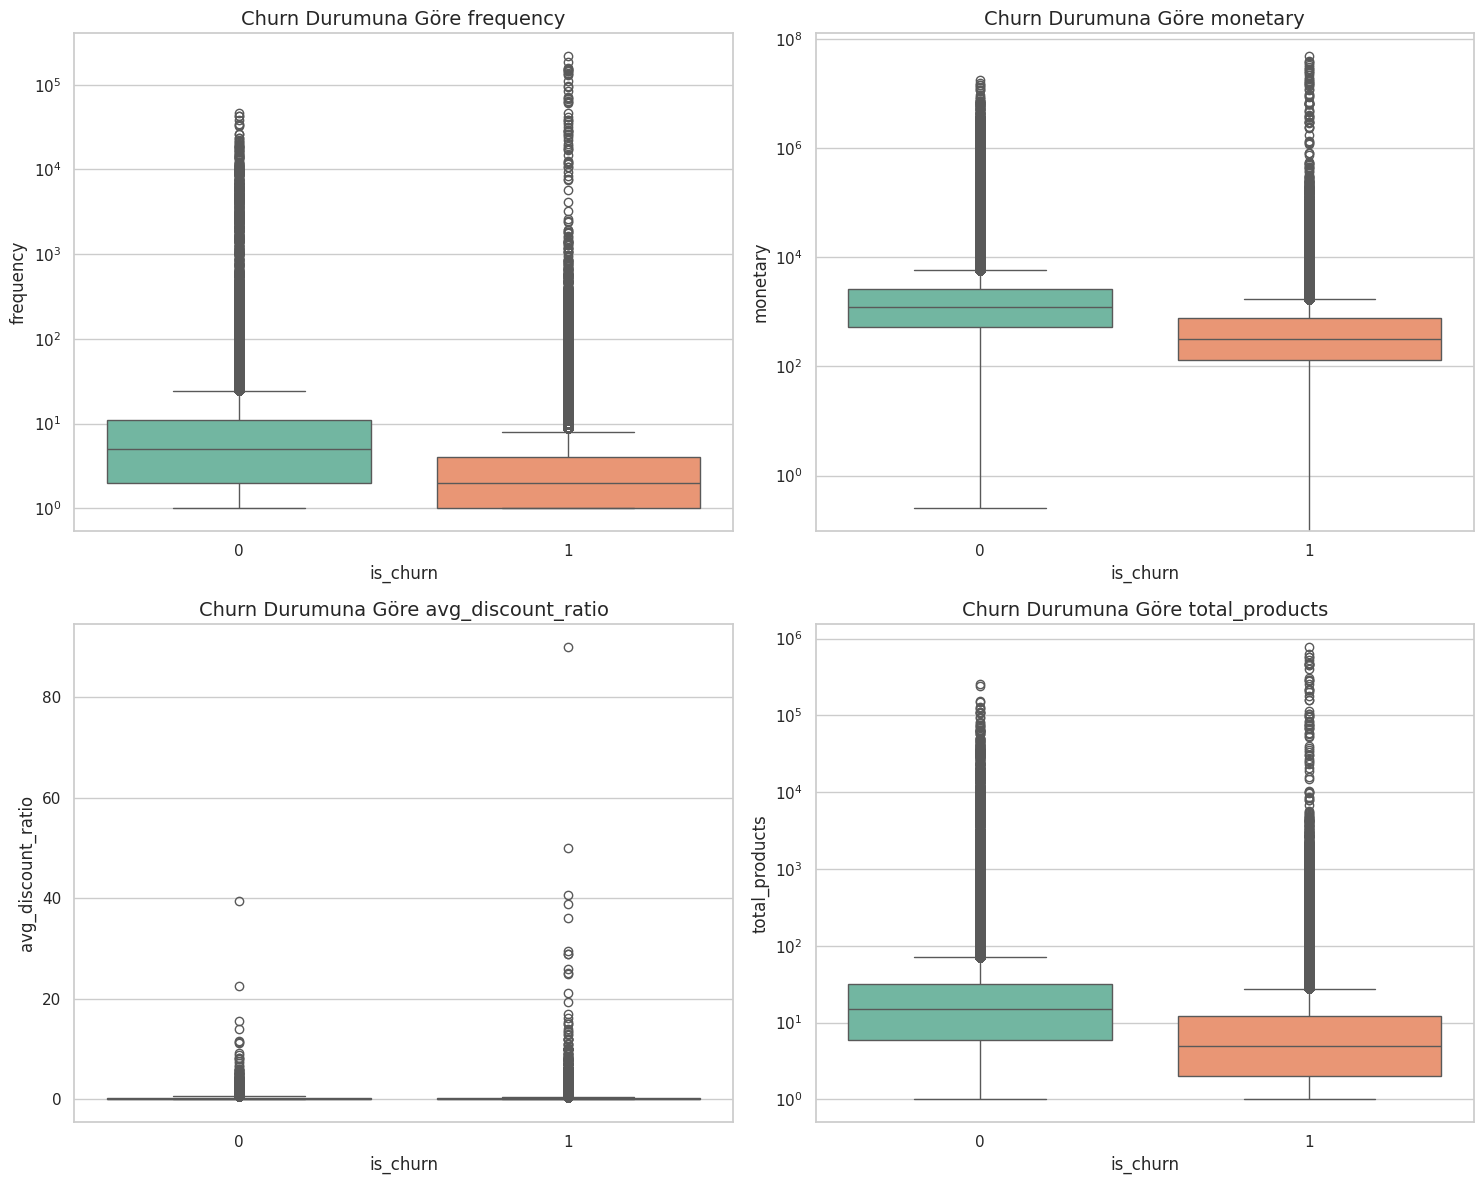

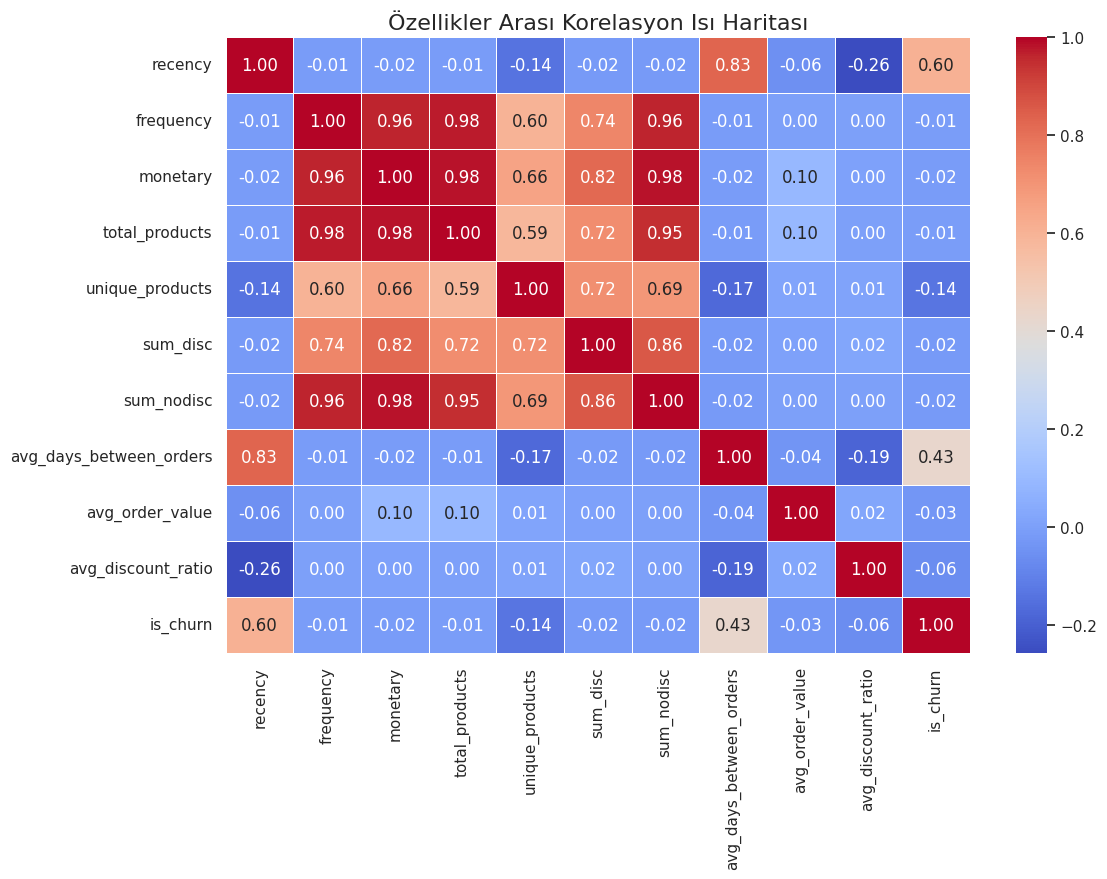

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik stilini ayarlayalım
sns.set_theme(style="whitegrid")

# 1. Sayısal Değişkenlerin Dağılımı (Logaritmik Ölçekle)
# Frequency ve Monetary çok geniş aralıklı olduğu için boxplot en iyi sonucu verir
cols_to_plot = ['frequency', 'monetary', 'avg_discount_ratio', 'total_products']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x='is_churn', y=col, data=customer_df, ax=axes[i], palette="Set2")
    axes[i].set_title(f'Churn Durumuna Göre {col}', fontsize=14)
    # Değerler çok uçuksa logaritmik ölçek kullan
    if customer_df[col].max() > 1000:
        axes[i].set_yscale('log')

plt.tight_layout()
plt.show()

# 2. Korelasyon Isı Haritası
plt.figure(figsize=(12, 8))
# Sadece sayısal sütunları alalım ve hedef değişkenle ilişkiye bakalım
correlation = customer_df.drop(columns=['cust_id', 'last_purchase_date']).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Özellikler Arası Korelasyon Isı Haritası', fontsize=16)
plt.show()

In [3]:
import pandas as pd
import os

# Eğer customer_df tanımlı değilse dosyadan oku
if 'customer_df' not in locals():
    path = '/content/drive/MyDrive/EVE/customer_features_final.csv'
    if os.path.exists(path):
        customer_df = pd.read_csv(path)
        print("Veri dosyadan tekrar yüklendi.")
    else:
        print("Hata: Veri dosyası bulunamadı, lütfen önceki adımları kontrol edin.")

# avg_days_between_orders: Ortalama kaç günde bir geliyor?
# (Frequency > 1 olanlar için anlamlıdır)
if 'customer_df' in locals():
    customer_df['avg_days_between_orders'] = customer_df['recency'] / customer_df['frequency']
    print("Yeni özellikler başarıyla eklendi.")

# ÖNEMLİ NOT: 'recency' ve 'last_purchase_date' sütunlarını modelden çıkarmayı unutmayın!

Veri dosyadan tekrar yüklendi.
Yeni özellikler başarıyla eklendi.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Eksik feature'ları ve churn etiketini yeniden hesaplayalım (Eğer yükleme sonrası kaybolduysa)
if 'avg_order_value' not in customer_df.columns:
    customer_df['avg_order_value'] = customer_df['monetary'] / customer_df['frequency']

if 'avg_discount_ratio' not in customer_df.columns:
    # sum_disc / sum_nodisc hesaplaması
    customer_df['avg_discount_ratio'] = (customer_df['sum_disc'] / customer_df['sum_nodisc']).fillna(0)

if 'is_churn' not in customer_df.columns:
    customer_df['is_churn'] = (customer_df['recency'] > 90).astype(int)

# Bağımsız değişkenler (X) ve Hedef (y)
features = ['frequency', 'monetary', 'total_products', 'unique_products',
            'avg_discount_ratio', 'avg_order_value']

X = customer_df[features].fillna(0) # NaN değerleri temizle
y = customer_df['is_churn']

# Veriyi bölme (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Model hazırlığı tamamlandı. X_train_scaled şekli:", X_train_scaled.shape)

Model hazırlığı tamamlandı. X_train_scaled şekli: (5750775, 6)


In [7]:
# Sadece birden fazla kez gelen müşterilerin (Frequency > 1)
# alışveriş sıklığını kontrol edelim
mean_gap = customer_df[customer_df['frequency'] > 1]['avg_days_between_orders'].mean()
print(f"Müşterilerin ortalama alışveriş aralığı: {mean_gap:.2f} gün")

Müşterilerin ortalama alışveriş aralığı: 116.99 gün


In [8]:
# Churn tanımını 150 güne çekiyoruz (Ortalamanın biraz üzeri)
customer_df['is_churn'] = (customer_df['recency'] > 150).astype(int)

print(f"Yeni Churn Oranı (%150 Gün): %{customer_df['is_churn'].mean() * 100:.2f}")
print(customer_df['is_churn'].value_counts())

Yeni Churn Oranı (%150 Gün): %78.50
is_churn
1    5643306
0    1545163
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Özellikleri Belirleme (X)
# DİKKAT: 'recency' ve 'last_purchase_date' asla X içinde olmamalı!
features = ['frequency', 'monetary', 'total_products', 'unique_products',
            'avg_discount_ratio', 'avg_order_value']

X = customer_df[features].fillna(0)
y = customer_df['is_churn']

# 2. Train-Test Split (%80 - %20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Ölçeklendirme (Logistic Regression için kritik)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Modeli Eğitme
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# 5. Sonuçları Görme
y_pred = log_model.predict(X_test_scaled)
print("--- Logistic Regression (150 Gün Tanımı) Sonuçları ---")
print(classification_report(y_test, y_pred))

--- Logistic Regression (150 Gün Tanımı) Sonuçları ---
              precision    recall  f1-score   support

           0       0.66      0.19      0.29    309033
           1       0.81      0.97      0.89   1128661

    accuracy                           0.80   1437694
   macro avg       0.74      0.58      0.59   1437694
weighted avg       0.78      0.80      0.76   1437694



In [11]:
from sklearn.ensemble import RandomForestClassifier

# Sınıf dengesizliğini çözmek için 'class_weight' ekliyoruz
rf_model = RandomForestClassifier(n_estimators=100,
                                  max_depth=10,
                                  class_weight='balanced',
                                  n_jobs=-1,
                                  random_state=42)

# Not: Random Forest ölçeklendirme (Scaling) gerektirmez ama X_train_scaled kullansan da bozulmaz
rf_model.fit(X_train, y_train)

# Tahmin ve Rapor
y_pred_rf = rf_model.predict(X_test)
print("--- Random Forest Sonuçları ---")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Sonuçları ---
              precision    recall  f1-score   support

           0       0.44      0.78      0.56    309033
           1       0.92      0.72      0.81   1128661

    accuracy                           0.74   1437694
   macro avg       0.68      0.75      0.68   1437694
weighted avg       0.82      0.74      0.76   1437694



In [13]:
from xgboost import XGBClassifier

# Dengesizliği dengelemek için ağırlık hesabı (Negatifler / Pozitifler)
# Yaklaşık 1.1M / 309k = 3.6 gibi bir oran ama daha agresif (5) deneyelim
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=5, # Aktif müşterilere 5 kat daha fazla önem ver
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
print("--- XGBoost (Optimize Edilmiş) Sonuçları ---")
print(classification_report(y_test, y_pred_xgb))

--- XGBoost (Optimize Edilmiş) Sonuçları ---
              precision    recall  f1-score   support

           0       0.88      0.03      0.06    309033
           1       0.79      1.00      0.88   1128661

    accuracy                           0.79   1437694
   macro avg       0.84      0.52      0.47   1437694
weighted avg       0.81      0.79      0.71   1437694



In [14]:
from xgboost import XGBClassifier

# 1. Oranı Manuel Hesapla (Daha radikal bir ağırlık)
# Churn olanların (1) sayısı / Aktiflerin (0) sayısı
# 1.128.661 / 309.033 ≈ 3.65. Biz bunu 4 yapalım.
weight_ratio = 4

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4, # Karmaşıklığı azaltalım ki ezberlemesin
    learning_rate=0.1,
    scale_pos_weight=weight_ratio, # Aktif sınıfın ağırlığını artır
    tree_method='hist',
    # Bu iki parametre modelin daha iyi genelleme yapmasını sağlar
    subsample=0.5,
    colsample_bytree=0.5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
print("--- XGBoost (Agresif Dengeleme) Sonuçları ---")
print(classification_report(y_test, y_pred_xgb))

--- XGBoost (Agresif Dengeleme) Sonuçları ---
              precision    recall  f1-score   support

           0       0.86      0.06      0.10    309033
           1       0.79      1.00      0.88   1128661

    accuracy                           0.80   1437694
   macro avg       0.83      0.53      0.49   1437694
weighted avg       0.81      0.80      0.72   1437694



SHAP Summary Plot hazırlanıyor...


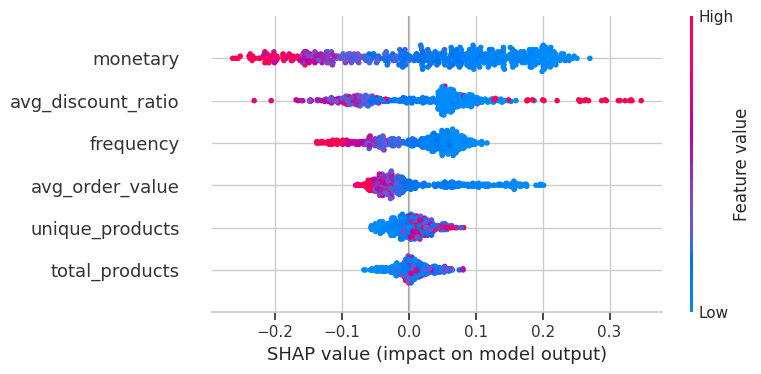

In [16]:
!pip install shap
import shap
import numpy as np

# 1. Örneklem seçelim (Hız için 500 örnek yeterli olabilir)
X_sample = X_test.sample(500, random_state=42)

# 2. Random Forest için explainer
# Not: rf_model eğitilmiş olmalı
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

# 3. Hata düzeltme: shap_values yapısını kontrol et ve doğru sınıfı seç
# Binary classification'da shap_values [samples, features, classes] veya list[classes] olabilir
if isinstance(shap_values, list):
    # Eğer liste ise pozitif sınıfı (Churn=1) seç
    actual_shap_values = shap_values[1]
elif len(shap_values.shape) == 3:
    # Eğer 3 boyutlu array ise son boyuttan sınıf 1'i seç
    actual_shap_values = shap_values[:, :, 1]
else:
    actual_shap_values = shap_values

# 4. Özet Grafik
print("SHAP Summary Plot hazırlanıyor...")
shap.summary_plot(actual_shap_values, X_sample)

In [17]:
# Her müşteri için churn olasılığını hesaplayalım
# rf_model (Şampiyon modelimiz) üzerinden gidiyoruz
customer_df['churn_probability'] = rf_model.predict_proba(X[features])[:, 1]

# En yüksek riskli 10 müşteriyi görelim
top_risky_customers = customer_df.sort_values(by='churn_probability', ascending=False).head(10)

print("--- En Yüksek Churn Riskine Sahip Müşteriler ---")
print(top_risky_customers[['cust_id', 'churn_probability', 'recency', 'monetary']])

# Bu listeyi Drive'a kaydedelim
customer_df[['cust_id', 'churn_probability']].to_csv('/content/drive/MyDrive/EVE/customer_churn_scores.csv', index=False)

--- En Yüksek Churn Riskine Sahip Müşteriler ---
                cust_id  churn_probability  recency  monetary
5717388         4530876           0.998072     1103      0.01
2043179  43780000763810           0.998072      997      0.01
4493265         4523695           0.998072     1104      0.01
3646012  43780000763017           0.998072      997      0.01
6636312         4499402           0.998072     1108      0.01
6477841         4499412           0.998072     1108      0.01
5531108         4531543           0.998072     1103      0.01
7103237         4531296           0.998072     1103      0.01
2953304          843778           0.998072      785      0.01
4203486         4530979           0.998072     1103      0.01
